In [21]:
%load_ext autoreload
%autoreload 2

In [22]:
import pulp
from dataclasses import dataclass
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import time


import energypredictionmodel as epm

In [23]:
@dataclass
class BatterySpecs:
    capacity: float     # capacity in MWh
    max_power: float    # max power in MW
    efficiency: float   # assume charge/discharge efficiency is the same
    SOC_min: float      # min charge in MWh
    SOC_max: float      # max charge in MWh
    dt: float           # time in hours that a dispatch is for (1/12 for NEM 5 minute dispatch)

@dataclass
class BESS:
    specs: BatterySpecs

    SOC_curr: float     # current SOC of the battery
    PnL: float          # PnL of the asset

    # charging or discharging
    def charge(self, power: float, price: float):
        energy = power * self.specs.dt      # total energy exchanged in this period
        self.SOC_curr += energy * self.specs.efficiency
        self.PnL -= energy * price
    def discharge(self, power: float, price: float):
        energy = power * self.specs.dt
        self.SOC_curr -= energy / self.specs.efficiency
        self.PnL += energy * price
    
    def dispatch(self, forecast, price: float):
        result = solve_dispatch_problem(self, forecast)
        charge = result["charge"][0]        # find the next recommended decision (charge/discharge) according to the forecast
        discharge = result["discharge"][0]
        self.charge(charge, price)          # carry out the dispatch, receiving the realised price
        self.discharge(discharge, price)


def solve_dispatch_problem(asset, prices):
    # rename some variables for easier access
    specs = asset.specs
    max_power = specs.max_power
    efficiency = specs.efficiency
    SOC_min = specs.SOC_min
    SOC_max = specs.SOC_max
    dt = specs.dt
    
    SOC_curr = asset.SOC_curr

    T = len(prices)
    periods = range(T)

    problem = pulp.LpProblem("battery_dispatch", pulp.LpMaximize)

    # decision variables with constraints on charge/discharge power and SOC
    charge = [pulp.LpVariable(f'charge_{t}', 0, max_power) for t in periods]
    discharge = [pulp.LpVariable(f'discharge_{t}', 0, max_power) for t in periods]

    SOC = [pulp.LpVariable(f'SOC_{t}', SOC_min, SOC_max) for t in range(T+1)]

    # objective is to maximise profit, which is the sum of (discharge - charge)*price*dt across all periods
    problem += pulp.lpSum(
        prices[t]*(discharge[t] - charge[t])*dt for t in periods
    )

    # add SOC dynamics
    problem += SOC[0] == SOC_curr

    for t in periods:
        problem += SOC[t+1] == SOC[t] + (efficiency*charge[t] - discharge[t]/efficiency)*dt

    # solve the optimisation problem
    problem.solve()
    # extract the optimal charge/discharge decisions and SOC trajectory
    p_c = np.array([pulp.value(charge[t]) for t in periods])
    p_d = np.array([pulp.value(discharge[t]) for t in periods])
    soc = np.array([pulp.value(SOC[t]) for t in range(T+1)])
    # return the results as a dict
    return {"charge": p_c,
            "discharge": p_d, 
            "SOC": soc}

def simulate_trading_rolling(data: pd.DataFrame, specs: BatterySpecs, windowsize: int):
    '''
    simulates trading with perfect foresight on a small window
    rolling optimisation
    '''
    asset = BESS(specs, specs.capacity/2, 0) # start at 50% full BESS
    prices = data["RRP"].to_numpy()
    times = data["SETTLEMENTDATE"].to_numpy()
    PnL_out = []
    SOC_out = []
    times_out = []
    i=0
    # repeat until our window goes outside of our testing period
    while i+windowsize<=prices.size:
        forecast = prices[i:i+windowsize]
        asset.dispatch(forecast, prices[i])
        PnL_out.append(asset.PnL)
        SOC_out.append(asset.SOC_curr)
        times_out.append(times[i])
        i+=1
    return pd.DataFrame({"time":times_out, "PnL":PnL_out, "SOC": SOC_out})
    

In [24]:
# plausible specifications for a medium-large scale BESS
specs = BatterySpecs(
    capacity=100,
    max_power=100,
    efficiency=0.92,
    SOC_min=10,
    SOC_max=90,
    dt=1/12,
)



In [ ]:
# train = training data (includes "duped" rows with various horizons, only contains frac proportion)
# test = test data ("     ", contains all data (frac=1)), for testing model MAE, RMSE etc

# raw = raw testing data, no duped rows with different horizons, used for backtesting

train, test, raw = epm.prepare_data(2024, 2025, range(1,289), "2025-12-01", frac=0.2)

In [56]:
raw.memory_usage(deep=True).sum()/1024**3

np.float64(0.0005986690521240234)

In [57]:
model, preds, y_test = epm.train_model(train, test)

[0]	validation_0-mae:67.90499
[100]	validation_0-mae:37.02858
[136]	validation_0-mae:38.75201
MAE:  36.70
RMSE: 48.37


In [46]:


def backtest_model(data, specs, windowsize, model):
    # start battery half full
    asset = BESS(specs, specs.capacity/2, 0)

    prices = data["RRP"].to_numpy()
    times = data["SETTLEMENTDATE"]
    demands = data["TOTALDEMAND"].to_numpy()

    PnL_out = []
    SOC_out = []
    times_out = []

    # timing accumulators
    t_forecast = 0.0
    t_dispatch = 0.0
    t_total = time.perf_counter()

    # start by predicting using t=0 -> predict t=1
    i = 1
    while i + windowsize <= len(prices):

        # forecast timing ---
        t0 = time.perf_counter()
        # get forecast
        forecast = epm.forecast(
            times.iloc[i-1],
            demands[i-1],
            prices[i-1],
            range(1, windowsize+1),
            model
        )
        t_forecast += time.perf_counter() - t0
        # forecast timing ---

        # time dispatch ---
        t0 = time.perf_counter()
        asset.dispatch(forecast, prices[i])
        t_dispatch += time.perf_counter() - t0
        # time dispatch ---

        # add data to output
        PnL_out.append(asset.PnL)
        SOC_out.append(asset.SOC_curr)
        times_out.append(times.iloc[i])

        # print occasional updates to get an indication of total time
        if i % 20 == 0:
            print(times.iloc[i], asset.PnL)

        i += 1

    t_total = time.perf_counter() - t_total

    print("\n--- TIMING BREAKDOWN ---")
    print(f"Total time:     {t_total:.3f}s")
    print(f"Forecast time:  {t_forecast:.3f}s ({t_forecast/t_total:.1%})")
    print(f"Dispatch time:  {t_dispatch:.3f}s ({t_dispatch/t_total:.1%})")
    print(f"Other time:     {t_total - t_forecast - t_dispatch:.3f}s")

    return pd.DataFrame({
        "time": times_out,
        "PnL": PnL_out,
        "SOC": SOC_out
    })

In [58]:
results_day_stronger = backtest_model(raw, specs, 288, model)

2025-12-01 01:45:00 -136.15999999999565
2025-12-01 03:25:00 -136.15999999999565
2025-12-01 05:05:00 -136.15999999999565
2025-12-01 06:45:00 -136.15999999999164
2025-12-01 08:25:00 -136.15999999995023
2025-12-01 10:05:00 205.95840000006606
2025-12-01 11:45:00 528.6592000000659
2025-12-01 13:25:00 1710.5074666667322
2025-12-01 15:05:00 2101.483466666732
2025-12-01 16:45:00 2234.4790029005667
2025-12-01 18:25:00 2234.4790029005667
2025-12-01 20:05:00 7741.229002900567
2025-12-01 21:45:00 8280.711669567325
2025-12-01 23:25:00 8280.711669567127
2025-12-02 01:05:00 8280.711669567148
2025-12-02 02:45:00 8280.711669567121
2025-12-02 04:25:00 8280.711669567121
2025-12-02 06:05:00 8280.711669567356
2025-12-02 07:45:00 8280.711669567054
2025-12-02 09:25:00 8281.966069567037
2025-12-02 11:05:00 8453.422069567034
2025-12-02 12:45:00 8996.173936233698
2025-12-02 14:25:00 9570.435269567028
2025-12-02 16:05:00 9714.435269567028
2025-12-02 17:45:00 9714.435269567028
2025-12-02 19:25:00 18200.2686029003

In [47]:
results_day = backtest_model(raw, specs, 288, model)

2025-12-01 01:45:00 0.0
2025-12-01 03:25:00 0.0
2025-12-01 05:05:00 -136.16
2025-12-01 06:45:00 -136.1599999999546
2025-12-01 08:25:00 -129.06052476102968
2025-12-01 10:05:00 178.5637655853855
2025-12-01 11:45:00 902.4804322520522
2025-12-01 13:25:00 1272.897098918719
2025-12-01 15:05:00 1980.2510989187185
2025-12-01 16:45:00 2138.8502368992204
2025-12-01 18:25:00 2138.8502368992204
2025-12-01 20:05:00 7556.266903565886
2025-12-01 21:45:00 8186.784236899156
2025-12-01 23:25:00 8186.7842368991005
2025-12-02 01:05:00 8186.784236899111
2025-12-02 02:45:00 8186.784236899086
2025-12-02 04:25:00 8186.784236899086
2025-12-02 06:05:00 8186.784236899043
2025-12-02 07:45:00 8186.784236898965
2025-12-02 09:25:00 8131.879323812121
2025-12-02 11:05:00 8545.618889281248
2025-12-02 12:45:00 8545.618889281248
2025-12-02 14:25:00 9250.05755594791
2025-12-02 16:05:00 9422.729555947908
2025-12-02 17:45:00 9422.729555947908
2025-12-02 19:25:00 10475.812889281242
2025-12-02 21:05:00 16529.487555947908
2025

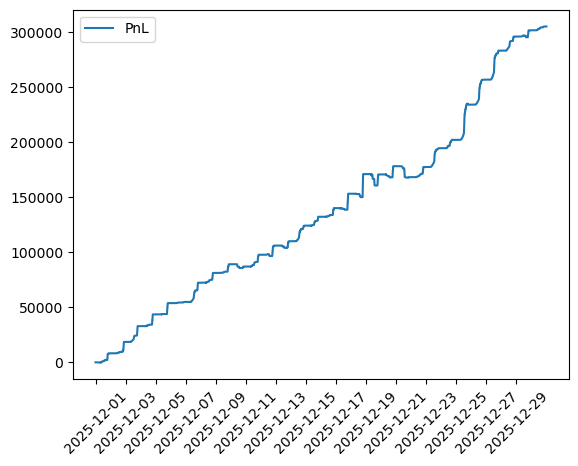

In [51]:
plt.plot(results_day["time"], results_day["PnL"], label="PnL")
plt.xticks(results_day["time"][::576], rotation=45)
plt.legend()

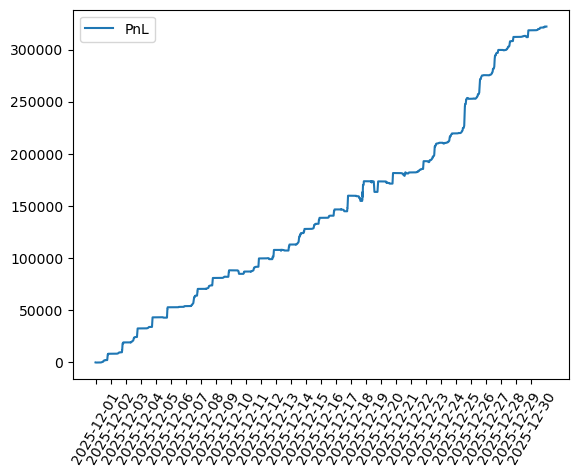

In [63]:
plt.plot(results_day_stronger["time"], results_day_stronger["PnL"], label="PnL")
plt.xticks(results_day_stronger["time"][::288], rotation=60)
plt.legend()

In [60]:
results_day_stronger

,time,PnL,SOC
0,2025-12-01 00:10:00,-30.833333,40.942029
1,2025-12-01 00:15:00,-61.666667,31.884058
2,2025-12-01 00:20:00,-74.493333,28.115942
3,2025-12-01 00:25:00,-74.493333,28.115942
4,2025-12-01 00:30:00,-105.326667,19.057971
...,...,...,...
8635,2025-12-30 23:45:00,322030.047325,10.000000
8636,2025-12-30 23:50:00,322030.047325,10.000000
8637,2025-12-30 23:55:00,322030.047325,10.000000
8638,2025-12-31 00:00:00,322030.047325,10.000000


In [ ]:
results_short = backtest_model(raw, specs, 20, model)

2025-12-01 01:45:00 -10.049333333333308
2025-12-01 03:25:00 -203.7593333333231
2025-12-01 05:05:00 -66.49562826665641
2025-12-01 06:45:00 17.841571733333218
2025-12-01 08:25:00 167.82943839999984
2025-12-01 10:05:00 658.6198383999997
2025-12-01 11:45:00 967.9446383999995
2025-12-01 13:25:00 1708.4366383999993
2025-12-01 15:05:00 2477.037571733332
2025-12-01 16:45:00 2761.838836719998
2025-12-01 18:25:00 2999.4037402833246
2025-12-01 20:05:00 3663.6537402833246
2025-12-01 21:45:00 10264.82307361684
2025-12-01 23:25:00 10264.82307361687
2025-12-02 01:05:00 6839.9064069502165
2025-12-02 02:45:00 9835.41374028354
2025-12-02 04:25:00 9835.41374028354
2025-12-02 06:05:00 9835.41374028361
2025-12-02 07:45:00 9806.84414028343
2025-12-02 09:25:00 9794.704540283441
2025-12-02 11:05:00 9935.709340283436
2025-12-02 12:45:00 10170.000540283434
2025-12-02 14:25:00 11042.927206950095
2025-12-02 16:05:00 11356.572273616759
2025-12-02 17:45:00 11896.817270978083
2025-12-02 19:25:00 11678.107804311418
2